In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines, prunning
from models.gmp import GMP
from models.leann import LEANN
import matplotlib.pyplot as plt
import numpy as np
import torch


Load data from files and init acpr meter

In [3]:
M = 5

dataset_path = "datasets/Custom_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.cut_signals(M)
container.get_gained_signals()
print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )



gain: 7.750391483306885


In [4]:
frame_length = 64
batch_size = 128
batch_size_eval = 2048

# pa_train_loader, pa_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval)
# dla_train_loader, dla_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="dla")
# ila_train_loader, ila_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="ila")

feature_extractor = data_loader.build_LEANN_features
pa_train_loader, pa_val_loader, pa_input_norm, pa_target_norm = data_loader.build_nn_dataloaders(container, 
                                                                                            batch_size=batch_size, 
                                                                                            batch_size_eval=batch_size_eval, 
                                                                                            arch="pa",
                                                                                            features_extractor=feature_extractor,
                                                                                            normalize_method='standard',
                                                                                            M=M)
# dla_train_loader, dla_val_loader, dla_input_norm, dla_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                                             batch_size=batch_size, 
#                                                                                             batch_size_eval=batch_size_eval,
#                                                                                             arch="dla",
#                                                                                             features_extractor=feature_extractor,
#                                                                                             normalize_method='standard',
#                                                                                             M=M)
# ila_train_loader, ila_val_loader, ila_input_norm, ila_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                                             batch_size=batch_size, 
#                                                                                             batch_size_eval=batch_size_eval,
#                                                                                             arch="ila",
#                                                                                             features_extractor=feature_extractor,
#                                                                                             normalize_method='standard',
#                                                                                             M=M)

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse

PA model

In [5]:
# pa_train_loader = [(x_train, y_train)]
# pa_val_loader = [(x_val, y_val)]
# pa_val_loader = pa_train_loader


pa_degree = 6
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = GMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 100
lr = 0.01

optimizer = torch.optim.AdamW(pa_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
      pa_model.save_weights()
utils.freeze_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=container.val_input)
pa_nmse = metrics.compute_nmse(y_val_pa, container.val_output)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 936
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
Model NMSE: -40.75


In [6]:

with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = learning.net_inference(net=pa_model, x=container.val_input)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=5))

-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                     Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
             aten::einsum         0.61%     232.700us        38.18%      14.447ms       4.816ms             3  
              aten::copy_        30.46%      11.527ms        30.46%      11.527ms     960.542us            12  
            aten::reshape         1.23%     466.500us        21.49%       8.131ms       1.355ms             6  
                aten::mul        20.74%       7.846ms        20.74%       7.846ms       2.615ms             3  
              aten::clone         0.11%      41.100us        20.13%       7.619ms       2.540ms             3  
-------------------------  ------------  ------------  ------------  ------------  ------------  -------

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


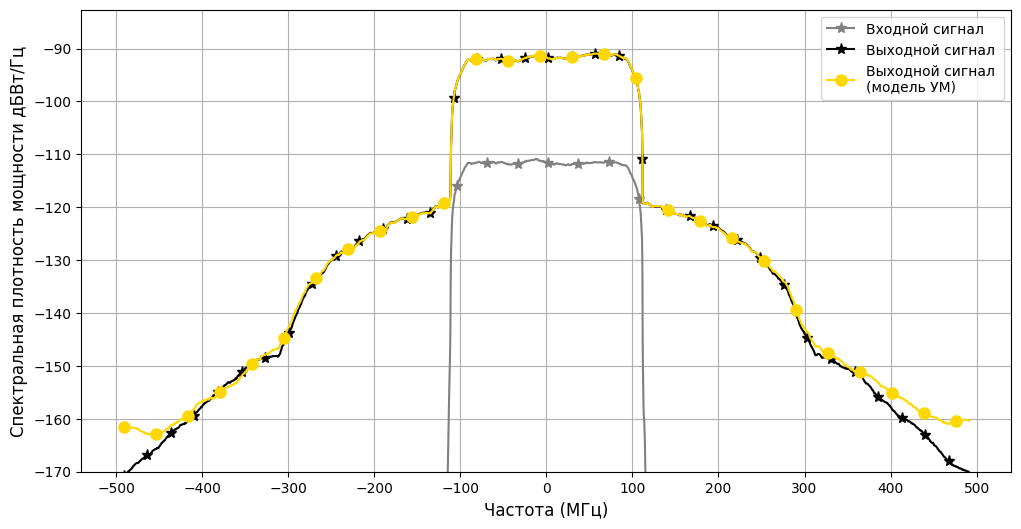

In [7]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


ILC DPD grad

In [6]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:39
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:25
NMSE на выходе усилителя (ILC): -70.27 db


In [7]:
ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
                                                                            batch_size=batch_size, 
                                                                            batch_size_eval=batch_size_eval,
                                                                            arch="ilc",
                                                                            features_extractor=feature_extractor,
                                                                            normalize_method='standard',
                                                                            M=M)

In [8]:
L1 = 6
L2 = 64
L3 = 8
K = 2

leann_model_ilc = LEANN(M=M, L2=L2, L3=L3, K=K, L1=L1, model_name="ilc")
print(f"total_params: {leann_model_ilc.count_params()}")

lr = 0.001
epochs = 300

optimizer = torch.optim.AdamW(leann_model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not leann_model_ilc.load_weights():
    learning.train(net=leann_model_ilc, 
        criterion=criterion, 
        optimizer=optimizer, 
        train_loader=ilc_train_loader, 
        val_loader=ilc_val_loader, 
        n_epochs=epochs, 
        metric_criterion=metric_criterion,
        scheduler=scheduler)
    leann_model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input_orig)
x_val_in = feature_extractor(norm_val_input, M)

y_before_pa = learning.net_inference(net=leann_model_ilc, model_type="LEANN", x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=leann_model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in, model_type="LEANN")

nmse_ilc = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {nmse_ilc:.2f}")

acpr_ilc = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {acpr_ilc[0]:.2f} {acpr_ilc[1]:.2f}")

total_params: 1948
Model weights loaded from model_params/ilc_LEANN_M_5_L1_6_L2_64_L3_8_K_2.pt
Model NMSE: -49.89
Model ACPR: -63.06 -63.74


Layer-wise sparsity report
<root>.lea_1_weight         | nonzero:      384 /      384 (100.00%)
<root>.lea_1_bias           | nonzero:      384 /      384 (100.00%)
<root>.lea_k_weight         | nonzero:      512 /      512 (100.00%)
<root>.lea_k_bias           | nonzero:      512 /      512 (100.00%)
<root>                   | LAYER TOTAL:     1792 /     1792 (100.00%)
------------------------------------------------------------------------
fir.weight               | nonzero:      144 /      144 (100.00%)
fir.bias                 | nonzero:       12 /       12 (100.00%)
fir                      | LAYER TOTAL:      156 /      156 (100.00%)
------------------------------------------------------------------------
MODEL TOTAL: nonzero 1948 / 1948 (100.00%)


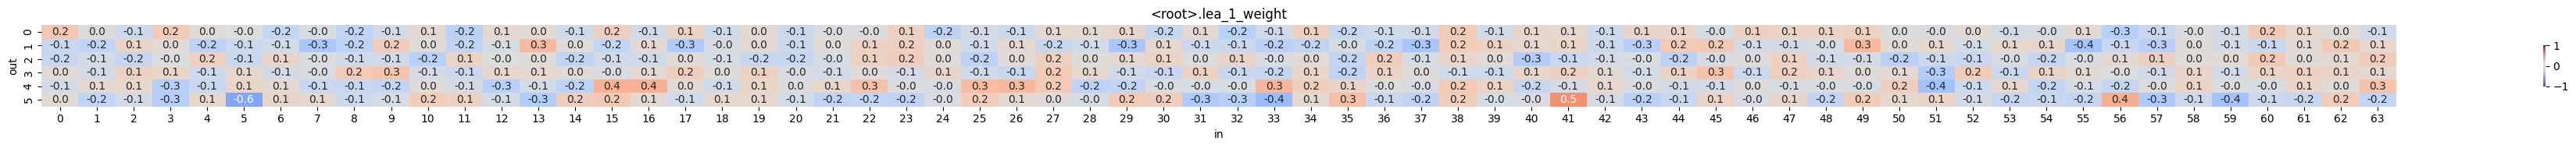

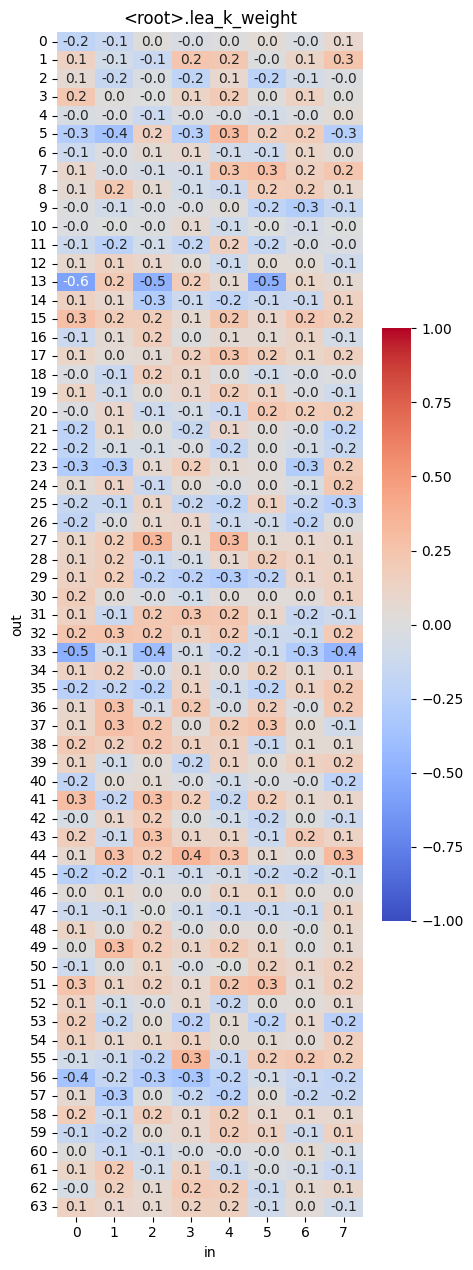

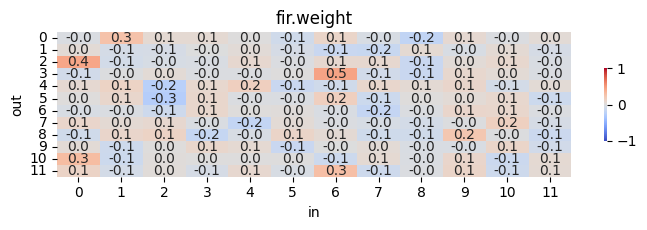

In [17]:
prunning.log_layerwise_sparsity(leann_model_ilc, only_weights=False)
plotting.plot_weight_heatmaps(leann_model_ilc, vmin=-1, vmax=1)

In [86]:
pleann_model = LEANN(M=M,L2=L2,L3=L3,K=K,L1=L1,model_name="ilc_prune")
is_load_pruned = pleann_model.load_weights()

if not is_load_pruned:
    pretrained_model = LEANN(M=M,L2=L2,L3=L3,K=K,L1=L1,model_name="ilc")

    is_load_pretrain = False

    if pretrained_model.load_weights():
        pleann_model.load_state_dict(pretrained_model.state_dict())
        is_load_pretrain = True
        print("Loaded pretrained ILC weights")
    else:
        raise RuntimeError("Failed to load pretrained ilc model")


# pleann_model = LEANN(M=M, L2=L2, L3=L3, K=K, L1=L1, model_name="ilc_prune")
print(f"total_params: {pleann_model.count_params()}")

lr = 0.001
lr1 = 0.0001

epochs = 300
epochs1 = 200
lambda_reg = 1e-4

# baseline
# alpha = 0.001
# tau = 0.001

# compress 30%
alpha = 0.015
tau = 0.001

# -47
# alpha = 0.002
# tau = 0.002

criterion_reg = metrics.RegLoss(pleann_model, original_loss=metrics.compute_mse, lambda_reg=lambda_reg)

optimizer = torch.optim.AdamW(pleann_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load_pruned:
    if not is_load_pretrain:
        learning.train(net=pleann_model, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=ilc_train_loader, 
            val_loader=ilc_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
        
        norm_val_input = ilc_input_norm.transform(container.val_input_orig)
        x_val_in = feature_extractor(norm_val_input, M)
        casc_ilc_eval = utils.CascadeModel(model_1=pleann_model, model_2=pa_model, normalizer=ilc_target_norm)
        y_val_ilc_prune = learning.net_inference(net=casc_ilc_eval, x=x_val_in, model_type="LEANN")
        nmse_ilc_prune = metrics.compute_nmse(y_val_ilc_prune, container.val_output_target)
        print(f"Model NMSE: {nmse_ilc_prune:.2f}")
        acpr_ilc_prune = metrics.calculate_acpr(y_val_ilc_prune, acpr_meter)
        print(f"Model ACPR: {acpr_ilc_prune[0]:.2f} {acpr_ilc_prune[1]:.2f}")

    optimizer = torch.optim.AdamW(pleann_model.parameters(), lr=lr1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    learning.train(net=pleann_model, 
        criterion=criterion_reg, 
        optimizer=optimizer, 
        train_loader=ilc_train_loader, 
        val_loader=ilc_val_loader, 
        n_epochs=epochs1, 
        metric_criterion=metric_criterion,
        scheduler=scheduler)
    
    prunning.leann_prune(pleann_model, alpha=alpha, tau=tau)
    
    pleann_model.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input_orig)
x_val_in = feature_extractor(norm_val_input, M)

casc_ilc_eval = utils.CascadeModel(model_1=pleann_model, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc_prune = learning.net_inference(net=casc_ilc_eval, x=x_val_in, model_type="LEANN")

nmse_ilc_prune = metrics.compute_nmse(y_val_ilc_prune, container.val_output_target)
print(f"Model NMSE: {nmse_ilc_prune:.2f}")

acpr_ilc_prune = metrics.calculate_acpr(y_val_ilc_prune, acpr_meter)
print(f"Model ACPR: {acpr_ilc_prune[0]:.2f} {acpr_ilc_prune[1]:.2f}")


No saved weights found at model_params/ilc_prune_LEANN_M_5_L1_6_L2_64_L3_8_K_2.pt, initializing new parameters.
Model weights loaded from model_params/ilc_LEANN_M_5_L1_6_L2_64_L3_8_K_2.pt
Loaded pretrained ILC weights
total_params: 1948
===Start training===
Epoch 0000 — train_loss: -0.00023740, val_loss: -0.00024998, val_NMSE: -48.33, lr: 0.0001
Epoch 0001 — train_loss: -0.00025449, val_loss: -0.00026416, val_NMSE: -48.48, lr: 0.0001
Epoch 0002 — train_loss: -0.00026541, val_loss: -0.00027333, val_NMSE: -48.55, lr: 0.0001
Epoch 0003 — train_loss: -0.00027321, val_loss: -0.00028031, val_NMSE: -48.40, lr: 0.0001
Epoch 0004 — train_loss: -0.00028063, val_loss: -0.00028408, val_NMSE: -47.72, lr: 0.0001
Epoch 0005 — train_loss: -0.00028588, val_loss: -0.00029281, val_NMSE: -48.68, lr: 0.0001
Epoch 0006 — train_loss: -0.00029109, val_loss: -0.00029718, val_NMSE: -48.51, lr: 0.0001
Epoch 0007 — train_loss: -0.00029499, val_loss: -0.00029965, val_NMSE: -48.24, lr: 0.0001
Epoch 0008 — train_los

Layer-wise sparsity report
<root>.lea_1_weight         | nonzero:      150 /      384 (39.06%)
<root>.lea_1_bias           | nonzero:      384 /      384 (100.00%)
<root>.lea_k_weight         | nonzero:      187 /      512 (36.52%)
<root>.lea_k_bias           | nonzero:      512 /      512 (100.00%)
<root>                   | LAYER TOTAL:     1233 /     1792 (68.81%)
------------------------------------------------------------------------
fir.weight               | nonzero:      115 /      144 (79.86%)
fir.bias                 | nonzero:       12 /       12 (100.00%)
fir                      | LAYER TOTAL:      127 /      156 (81.41%)
------------------------------------------------------------------------
MODEL TOTAL: nonzero 1360 / 1948 (69.82%)


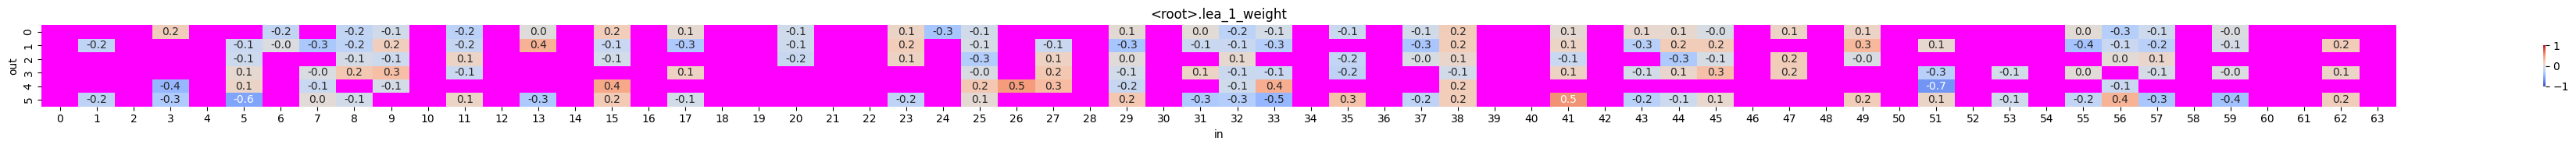

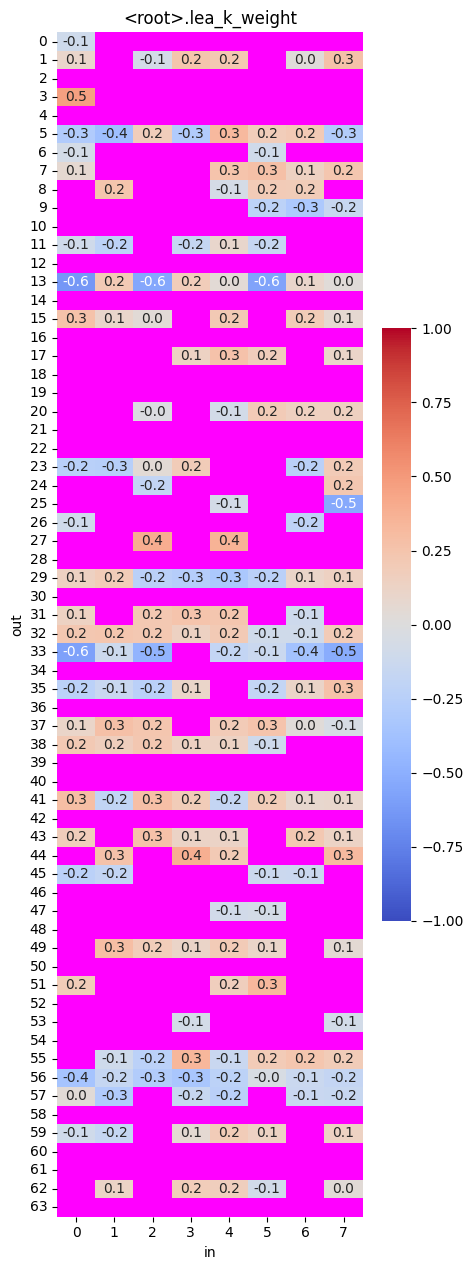

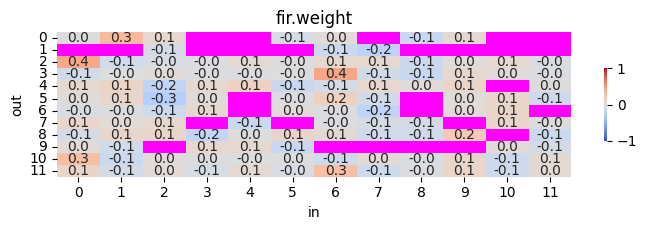

In [87]:
prunning.log_layerwise_sparsity(pleann_model, only_weights=False)
plotting.plot_weight_heatmaps(pleann_model, vmin=-1, vmax=1)

Metrics

In [84]:
nmse_after_pa = metrics.compute_nmse(y_val_pa, container.val_output_target)

print(f"NMSE на выходе усилителя (без DPD): {nmse_after_pa:.2f} db")

# print(f"NMSE на выходе усилителя (DLA DPD): {nmse_dla:.2f} db")

# print(f"NMSE на выходе усилителя (ILA DPD): {nmse_ila:.2f} db")

print(f"NMSE на выходе усилителя (ILC DPD): {nmse_ilc:.2f} db")

print(f"NMSE на выходе усилителя (ILC DPD): {nmse_ilc_prune:.2f} db")


NMSE на выходе усилителя (без DPD): -9.46 db
NMSE на выходе усилителя (ILC DPD): -49.89 db
NMSE на выходе усилителя (ILC DPD): -49.29 db


In [67]:
x_val_acpr = metrics.calculate_acpr(container.val_input, acpr_meter)
y_val_acpr = metrics.calculate_acpr(container.val_output, acpr_meter)
y_val_pa_acpr = metrics.calculate_acpr(y_val_pa, acpr_meter)
y_val_target_acpr = metrics.calculate_acpr(container.val_output_target, acpr_meter)

# y_lin_dla_acpr = metrics.calculate_acpr(y_val_dla, acpr_meter)
# y_lin_ila_acpr = metrics.calculate_acpr(y_val_ila, acpr_meter)
y_lin_ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)

print(f"x_val_acpr:         {x_val_acpr[0]:.2f} {x_val_acpr[1]:.2f}")
print(f"y_val_acpr:         {y_val_acpr[0]:.2f} {y_val_acpr[1]:.2f}")
print(f"y_val_pa_acpr:      {y_val_pa_acpr[0]:.2f} {y_val_pa_acpr[1]:.2f}")
print(f"y_val_target_acpr:  {y_val_target_acpr[0]:.2f} {y_val_target_acpr[1]:.2f}")

# print(f"lin_dla_acpr: {y_lin_dla_acpr[0]:.2f} {y_lin_dla_acpr[1]:.2f}")
# print(f"lin_ila_acpr: {y_lin_ila_acpr[0]:.2f} {y_lin_ila_acpr[1]:.2f}")
print(f"lin_ilc_acpr:       {y_lin_ilc_acpr[0]:.2f} {y_lin_ilc_acpr[1]:.2f}")

print(f"Model ACPR:         {acpr_ilc_prune[0]:.2f} {acpr_ilc_prune[1]:.2f}")


x_val_acpr:         -71.27 -71.27
y_val_acpr:         -41.14 -40.69
y_val_pa_acpr:      -41.20 -40.75
y_val_target_acpr:  -89.06 -89.06
lin_ilc_acpr:       -63.06 -63.74
Model ACPR:         -63.70 -64.33


In [88]:
nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

u_k_acpr = metrics.calculate_acpr(u_k_val, acpr_meter)
u_k_pa_acpr = metrics.calculate_acpr(u_k_pa, acpr_meter)

print(f"u_k_acpr: {u_k_acpr}")
print(f"u_k_pa_acpr: {u_k_pa_acpr[0]:.2f} {u_k_pa_acpr[1]:.2f}") 

NMSE на выходе усилителя (ILC): -70.27 db
u_k_acpr: [-39.18171389 -40.59172436]
u_k_pa_acpr: -80.74 -79.25


Spectrum

In [69]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_dpd_dla = metrics.power_spectrum(y_dpd_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ila = metrics.power_spectrum(y_dpd_ila, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ilc = metrics.power_spectrum(y_dpd_ilc, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_val_dla = metrics.power_spectrum(y_val_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_val_ila = metrics.power_spectrum(y_val_ila, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc_prune = metrics.power_spectrum(y_val_ilc_prune, container.input_signal_fs, container.nperseg, window_size)


# _, spectrum_u_k = metrics.power_spectrum(u_k_val, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size)

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


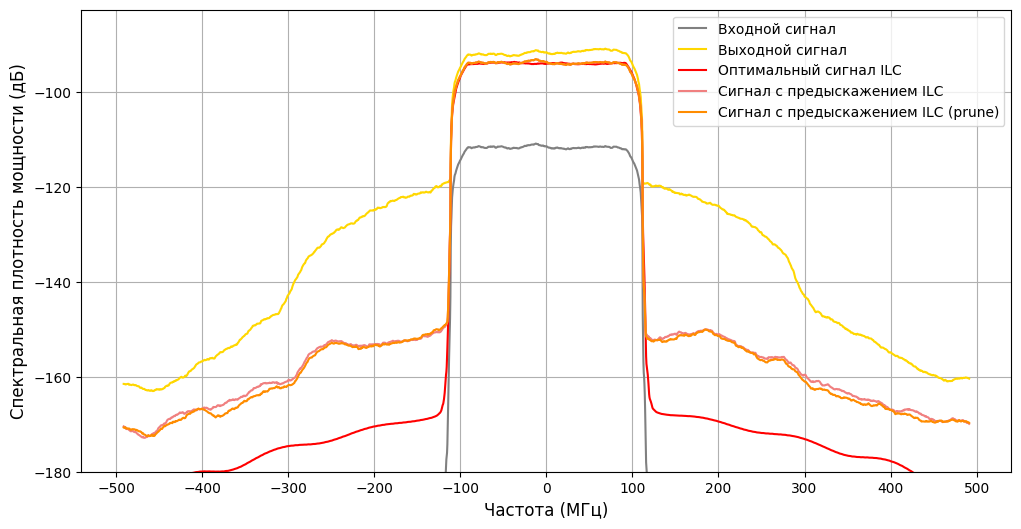

In [70]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC')
# plt.plot(freqs / 1e6, spectrum_y_val_dla, color='darkorange', label='Сигнал с предыскажением DLA')
# plt.plot(freqs / 1e6, spectrum_y_val_ila, color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='lightcoral', label='Сигнал с предыскажением ILC')
plt.plot(freqs / 1e6, spectrum_y_val_ilc_prune, color='darkorange', label='Сигнал с предыскажением ILC (prune)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.ylim(bottom=-180)
plt.grid()
plt.show()



In [7]:
def estimate_leann_params(M, L1, L2, L3):
    return (
        4*(M+1)*L1
        + 2*L1
        + 2*L1*L2
        + 2*L2*L3
    )

def is_valid(M, L1, L2, L3, low=1900, high=2100):
    p = estimate_leann_params(M, L1, L2, L3)
    return low <= p <= high


valid_configs = []

# L1_values = [4, 6, 8]
# L2_values = [16, 24, 32, 48, 64]
# L3_values = [8, 16, 24, 32]
# K_values = [2, 3]

L1_values = [4, 6]
L2_values = [64, 80, 96, 128]
L3_values = [4, 6, 8]
K_values = [2]

for L1 in L1_values:
    for L2 in L2_values:
        for L3 in L3_values:
            
            # разумное ограничение
            if L3 > L2:
                continue

            params = estimate_leann_params(M, L1, L2, L3)

            if 1900 <= params <= 2100:
                for K in K_values:
                    valid_configs.append({
                        "L1": L1,
                        "L2": L2,
                        "L3": L3,
                        "K": K,
                        "params_est": params
                    })


results = []

for cfg in valid_configs:

    leann_train_props = {
        "M": M,
        "L1": cfg["L1"],
        "L2": cfg["L2"],
        "L3": cfg["L3"],
        "K": cfg["K"],
        "lr": 0.001,
        "epochs": 300,
        "acpr_meter": acpr_meter
    }

    pipeline = pipelines.SimplePipeline(
        container=container,
        train_props=leann_train_props,
        base_model=LEANN,
        pa_model=pa_model
    )
    
    params = pipeline.get_count_params()

    # дополнительная проверка (на всякий случай)
    if not (1900 <= params <= 2100):
        continue

    stats = pipeline.evaluate_with_statistics(arch='ilc', n_runs=3)
    agg = metrics.summarize_statistics(stats)

    results.append({
        "cfg": cfg,
        "params": params,
        "nmse": agg["nmse"]["mean"],
        "acpr_l": agg["acpr_l"]["mean"],
        "acpr_r": agg["acpr_r"]["mean"]
    })

    print(cfg, params, agg["acpr_l"]["mean"])


=== Run 1/3 ===
Run ILC
count_params: 2024
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:48
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:26
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.12757607, val_loss: 0.01093413, val_NMSE: -19.50, lr: 0.001
Epoch 0001 — train_loss: 0.00742146, val_loss: 0.00523853, val_NMSE: -22.69, lr: 0.001
Epoch 0002 — train_loss: 0.00447530, val_loss: 0.00353976, val_NMSE: -24.39, lr: 0.001
Epoch 0003 — train_loss: 0.00303818, val_loss: 0.00253749, val_NMSE: -25.84, lr: 0.001
Epoch 0004 — train_loss: 0.00213466, val_loss: 0.00168999, val_NMSE: -27.61, lr: 0.001
Epoch 0005 — train_loss: 0.00149488, val_loss: 0.00120673, val_NMSE: -29.07, lr: 0.001
Epoch 0006 — train_loss: 0.00104797, val_loss: 0.00075

{'L1': 6, 'L2': 64, 'L3': 8, 'K': 2, 'params_e...	1948	-48.82	-62.04	-62.95

In [9]:
import pandas as pd



df = pd.DataFrame(results)
df = df.sort_values('nmse')
print(df)

df.head()

                                                 cfg  params   nmse  acpr_l  \
2  {'L1': 6, 'L2': 64, 'L3': 8, 'K': 2, 'params_e...    1948 -48.82  -62.04   
4  {'L1': 6, 'L2': 96, 'L3': 4, 'K': 2, 'params_e...    2076 -48.45  -60.81   
0  {'L1': 4, 'L2': 80, 'L3': 8, 'K': 2, 'params_e...    2024 -48.03  -61.85   
3  {'L1': 6, 'L2': 80, 'L3': 6, 'K': 2, 'params_e...    2076 -47.82  -61.54   
1  {'L1': 4, 'L2': 96, 'L3': 6, 'K': 2, 'params_e...    2024 -47.67  -61.16   

   acpr_r  
2  -62.95  
4  -62.64  
0  -62.12  
3  -62.42  
1  -61.95  


,cfg,params,nmse,acpr_l,acpr_r
2,"{'L1': 6, 'L2': 64, 'L3': 8, 'K': 2, 'params_e...",1948,-48.82,-62.04,-62.95
4,"{'L1': 6, 'L2': 96, 'L3': 4, 'K': 2, 'params_e...",2076,-48.45,-60.81,-62.64
0,"{'L1': 4, 'L2': 80, 'L3': 8, 'K': 2, 'params_e...",2024,-48.03,-61.85,-62.12
3,"{'L1': 6, 'L2': 80, 'L3': 6, 'K': 2, 'params_e...",2076,-47.82,-61.54,-62.42
1,"{'L1': 4, 'L2': 96, 'L3': 6, 'K': 2, 'params_e...",2024,-47.67,-61.16,-61.95


In [ ]:

leann_train_props = {
    "M": M,
    "L1": 18,
    "L2": 16,
    "L3": 32,
    "K": 3,
    "lr": 0.001,
    "epochs": 300,
    "acpr_meter": acpr_meter
}

leann_pipeline = pipelines.SimplePipeline(container=container, 
                              train_props=leann_train_props, 
                              base_model=LEANN,
                              pa_model=pa_model)

count_params = leann_pipeline.get_count_params()


leann_stats = leann_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

leann_agg_stats = metrics.summarize_statistics(leann_stats)

leann_results = leann_pipeline.get_results()

leann_count = leann_results["ilc"]["count_params"]

final_leann_stats = {
        "Model": "LEANN",
        "Params": leann_count,
        "NMSE (dB)": leann_agg_stats["nmse"]["mean"],
        "ACPR left (dB)": leann_agg_stats["acpr_l"]["mean"],
        "ACPR right (dB)": leann_agg_stats["acpr_r"]["mean"],
    }

print(final_leann_stats)